## Dataset Provenance and Scientific Context

The CRCNS PVC-2 dataset used in this notebook contains extracellular spike recordings from neurons in the **primary visual cortex (V1) of anesthetized cats**, collected in the laboratory of **Yang Dan (UC Berkeley)**. These recordings were used in influential studies on how cortical neurons encode visual stimuli.

Two key publications based on this dataset are:

### 1. Touryan, Lau & Dan (2002) — *Isolation of relevant visual features from random stimuli for cortical complex cells*  
**Journal of Neuroscience, 22, 10811–10818**

This study used random stimulus ensembles and spike-triggered covariance methods to identify the stimulus features that drive **complex cells** in V1. It demonstrated that nonlinear receptive field components of cortical neurons can be recovered directly from spike responses.

### 2. Touryan, Felsen & Dan (2005) — *Spatial Structure of Complex Cell Receptive Fields Measured with Natural Images*  
**Neuron, 45, 781–791**

This later work extended the analysis to **natural image stimuli**, showing that complex-cell receptive fields can be described by a small number of oriented subunits. The results supported the classical **energy model** of visual cortical processing and provided an early example of nonlinear neural encoding under naturalistic stimulation.

## Why this dataset matters

This dataset is historically important because it helped establish modern approaches for studying neural coding using:

- spike-triggered average (STA)
- spike-triggered covariance (STC)
- nonlinear receptive field estimation
- natural stimulus encoding models

It remains highly relevant today for comparing classical neuroscience methods with modern machine learning models such as GLMs, CNNs, and neural system identification networks.

Based on archived correspondence from the original investigators, filenames encode:

YYMMDD.(chamber).(penetration)(cell number)(run number)(stimulus).(filetype)

Thus files such as `000413.b03bmsq1D.sa0`, `000413.b03cmsq1D.sa0`, and `000413.b03dmsq1D.sa0` correspond to the same recorded unit (`b03`) across different sequential runs (`b`, `c`, `d`) using the `msq1D` stimulus.

For the `msq1D` white-noise experiments, the `.log` field `StiW` specifies the stimulus width on the display in centimeters. The viewing distance was 114 cm, so 1 cm corresponds to approximately 0.5° of visual angle. Since the stimulus contains 16 bars, the spatial width of each bar is `StiW / 16` cm (≈ `0.5 * StiW / 16` degrees). The stimulus coordinate system was aligned to each neuron's preferred orientation and direction.

When plotting STA/STC filters, label x-axis as:

Position (deg visual angle)

using StiW.

That makes the notebook publication-quality.

- imsq1D.mat = temporal sequence of bar patterns

From the dataset documentation:

msq1D.mat = 1D M-sequence stimulus with 16 bars, 32767 frames
imsq1D.mat = inverted M-sequence stimulus with 512 frames

This gives you:

X = stimulus matrix (known input)
y = spikes (neural output)

That is a supervised learning problem.

You can fit:

linear receptive fields
Poisson GLMs
CNNs
RNNs
temporal filters

In [1]:
from pathlib import Path
import numpy as np

In [2]:
PROJECT_ROOT = Path.cwd()

In [3]:
from pathlib import Path

root = PROJECT_ROOT / "1D_white_noise/Spike_and_Log_Files"

units = [p.name for p in root.iterdir() if p.is_dir()]
print("Number of units:", len(units))
print(units[:10])

Number of units: 61
['000412.a01', '000413.b03', '000413.b04', '000413.b05', '000418.a01', '000419.a06', '000419.a07', '000419.a09', '000420.b02', '000503.a03']


In [4]:
def load_spikes(path):
    with open(path, "rb") as f:
        hdrchk = f.read(16)

        if b"DAN_SPK" in hdrchk:
            f.seek(828)
        else:
            f.seek(0)

        p = str(path)

        if ("mq" in p) or ("film02" in p) or ("film32" in p):
            dtype = "<u4"   # uint32, little-endian
        else:
            dtype = "<i4"   # int32, little-endian

        events = np.fromfile(f, dtype=dtype)

    events = events[events > 0]
    events_sec = events * 1e-4

    return events, events_sec

the first priority after isolating a neuron is to determine what kind of stimulus drives it best. The tuning run is therefore usually performed first as a calibration and characterization step.

For V1 neurons, especially in cat primary visual cortex, responses depend strongly on stimulus orientation, spatial frequency, position, contrast, and motion. If you do not know these preferences first, later experiments may be inefficient or even misleading.

to check if all of this is true later 

In [5]:
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


HEADER_BYTES = 828


def load_log_lines(log_path):
    raw = Path(log_path).read_bytes()
    text = raw.replace(b"\x00", b" ").decode(errors="ignore")
    return [line.strip() for line in text.splitlines() if line.strip()]


def search_log(lines, section, key, default="JQK"):
    """
    Approximate Python equivalent of fsearch_log.
    Works for lines containing section/key/value text.
    """
    key_l = key.lower()
    section_l = section.lower()

    candidates = []
    for line in lines:
        low = line.lower()
        if key_l in low:
            candidates.append(line)

    if not candidates:
        return default

    line = candidates[0]

    # Try common patterns:
    # Key value
    # Key = value
    # Section Key value
    line = re.sub(r"\s+", " ", line)
    line = line.replace("=", " ")

    parts = line.split()
    for i, p in enumerate(parts):
        if p.lower() == key_l.lower() and i + 1 < len(parts):
            return " ".join(parts[i + 1:])

    # fallback: remove key name from line
    idx = line.lower().find(key_l)
    if idx >= 0:
        return line[idx + len(key):].strip(" :=\t")

    return default


def numbers(s, dtype=float):
    return np.array(re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(s)), dtype=dtype)


def read_sa0(path, refresh_rate=120, remote_refresh_rate=120):
    """
    Reads .sa0 spike file.

    Original MATLAB:
        data = fread(..., 'int32')
        data = data * refresh_rate / remote_refresh_rate
    These values are still in 1/10000 sec units after correction.
    """
    with open(path, "rb") as f:
        f.seek(HEADER_BYTES)
        data = np.fromfile(f, dtype="<i4")

    data = data.astype(float) * refresh_rate / remote_refresh_rate
    return data


def retrieve_log(path, filename, channels=None):
    """
    Python equivalent of fretrieve_log.m for tuning curve logs.
    """
    path = Path(path)
    log_path = path / filename
    lines = load_log_lines(log_path)

    flog = {
        "path": str(path),
        "log_file_name": filename,
    }

    file_type = search_log(lines, "FileInfo", "FileType", "JQK")
    file_version = search_log(lines, "FileInfo", "FileVersion", "JQK")
    test_type = search_log(lines, "TestInfo", "TestType", "JQK")

    flog["file_type"] = file_type
    flog["file_version"] = file_version
    flog["test_type"] = test_type
    flog["test_name"] = search_log(lines, "TestInfo", "Testname", filename)

    # The MATLAB checks these strictly. Here we keep parsing even if the text differs.
    remote_rr = numbers(search_log(lines, "TestInfo", "RemoteRefreshRate", "1"))
    rr = numbers(search_log(lines, "TestInfo", "RefreshRate", "1"))

    flog["remote_refresh_rate"] = float(remote_rr[0]) if len(remote_rr) else 1.0
    flog["refresh_rate"] = float(rr[0]) if len(rr) else flog["remote_refresh_rate"]

    tc_mode = search_log(lines, "TunningCurve", "TCMode", "JQK")
    old_style = tc_mode == "JQK"
    if old_style:
        tc_mode = "direction"

    flog["tc_mode"] = tc_mode
    flog["gratings_type"] = search_log(lines, "TunningCurve", "GratingsType", "JQK")

    def get_float(new_key, old_key=None, default="9999"):
        val = search_log(lines, "TunningCurve", new_key, default)
        if old_style and old_key is not None:
            val = search_log(lines, "TunningCurve", old_key, default)
        arr = numbers(val)
        return float(arr[0]) if len(arr) else float(default)

    def get_int(new_key, old_key=None, default="1"):
        val = search_log(lines, "TunningCurve", new_key, default)
        if old_style and old_key is not None:
            val = search_log(lines, "TunningCurve", old_key, default)
        arr = numbers(val, int)
        return int(arr[0]) if len(arr) else int(default)

    flog["ori_x"] = get_float("OriX")
    flog["ori_y"] = get_float("OriY")
    flog["gratings_w"] = get_float("GratingsW", "Width")
    flog["gratings_h"] = get_float("GratingsH", "Height")
    flog["gratings_spatial_frequency"] = get_float("GratingsSpatialFrequency", "SpatialFrequency")
    flog["gratings_velocity"] = get_float("GratingsVelocity", "Velocity")
    flog["bar_w"] = get_float("BarW")
    flog["bar_h"] = get_float("BarH")
    flog["inner_direction"] = get_float("InnerDirection")
    flog["outer_direction"] = get_float("OuterDirection")
    flog["circle_mask"] = search_log(lines, "TunningCurve", "CircleMask", "JQK")

    flog["single_test_time"] = get_int("SingleTestTime", "SingleTime", "1")
    flog["interval"] = get_int("Interval", default="0")
    flog["repeats"] = get_int("Repeats", default="1")
    flog["data_points"] = get_int("DataPoints", default="1")

    direction_test_mode = search_log(lines, "TunningCurve", "DirectionTestMode", "JQK")
    if old_style:
        direction_test_mode = "default"
    flog["direction_test_mode"] = direction_test_mode

    flog["direction_number"] = get_int("DirectionNumber", "Directions", "2")

    if old_style:
        flog["data_points"] = flog["direction_number"]

    # Lists
    direction_raw = search_log(lines, "TunningCurve", "DirectionList", "1 0")
    if old_style:
        direction_raw = search_log(lines, "TunningCurve", "DirectionSequence", "1 0")
    direction_nums = numbers(direction_raw)

    if old_style:
        flog["direction_list"] = direction_nums
    else:
        flog["direction_list"] = direction_nums[1:]

    spatial_nums = numbers(search_log(lines, "TunningCurve", "SpatialList", "1 0"))
    temporal_nums = numbers(search_log(lines, "TunningCurve", "TemporalList", "1 0"))
    test_nums = numbers(search_log(lines, "TunningCurve", "TestSequence", "1 0"), int)

    flog["spatial_list"] = spatial_nums[1:]
    flog["temporal_list"] = temporal_nums[1:]

    if old_style:
        flog["test_sequence"] = (flog["direction_list"] / (360 / flog["direction_number"])).astype(int)
    else:
        flog["test_sequence"] = test_nums[1:].astype(int)

    # Spike files
    if channels is None:
        channel_letters = [chr(ord("a") + i) for i in range(26)]
    else:
        channel_letters = [chr(ord("a") + c) if isinstance(c, int) else c for c in channels]

    spike_files = []
    for ch in channel_letters:
        channel_on = False
        for cluster in range(6):
            key = f"SpikeFile{ch}{cluster}"
            sf = search_log(lines, "DataFile", key, "JQK")
            if sf != "JQK":
                channel_on = True
                spike_files.append(sf.split()[0])
        if not channel_on:
            break

    flog["spike_files"] = spike_files

    # Load spikes
    spikes = []
    for sf in spike_files:
        spk = read_sa0(
            path / sf,
            refresh_rate=flog["refresh_rate"],
            remote_refresh_rate=flog["remote_refresh_rate"],
        )
        spikes.append(spk)
    flog["spikes"] = spikes

    nfiles = len(spike_files)
    data_points = flog["data_points"]
    repeats = flog["repeats"]

    sums = np.zeros((nfiles, data_points))
    individuals = np.zeros((nfiles, repeats, data_points))

    full_step = flog["single_test_time"] + flog["interval"]

    for i, spks in enumerate(spikes):
        for spike_raw in spks:
            spike_sec = spike_raw / 10000.0

            step_index = int(np.floor(spike_sec / full_step))
            spike_remain = spike_sec - step_index * full_step

            step_index_1based = step_index + 1

            if (
                spike_remain > flog["interval"] * 0.5
                and spike_remain < flog["interval"] * 0.5 + flog["single_test_time"]
            ):
                if step_index < len(flog["test_sequence"]):
                    cond = int(flog["test_sequence"][step_index])
                    sums[i, cond] += 1

                    repeat_index = int(np.ceil(step_index_1based / data_points)) - 1
                    if 0 <= repeat_index < repeats:
                        individuals[i, repeat_index, cond] += 1

    flog["sum"] = sums
    flog["individuals"] = individuals
    flog["stds"] = individuals.std(axis=1, ddof=1) if repeats > 1 else np.zeros_like(sums)
    flog["stderrs"] = flog["stds"] / np.sqrt(repeats)
    flog["isvalid"] = True

    return flog

In [6]:
def plot_tori(info, flog):
    dirlist = np.sort(flog["test_sequence"][:flog["direction_number"]] *
                      (360 / flog["direction_number"]))

    rsum = info["rsum"]
    rr = info["rr"]
    f = info["f"]
    Pmax = info["Pxx"][:, info["prefind"]]

    tf = info["temporal_freq"]
    numdirs = flog["direction_number"]

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(info["spike_file"])

    # Polar plot
    ax1 = fig.add_subplot(2, 3, 1, projection="polar")
    theta = np.deg2rad(np.r_[dirlist, dirlist[0]])
    radius = np.r_[rsum, rsum[0]]
    ax1.plot(theta, radius, "-")
    ax1.set_title("Direction tuning")

    # Cartesian tuning curve
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(dirlist, rsum, "o-")
    ax2.set_xlabel("Direction / orientation (degrees)")
    ax2.set_ylabel("Spikes")
    ax2.grid(True)

    # Text
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.axis("off")
    cell_type = "complex" if info["relmod"] < 1 else "simple"

    txt = (
        f"{info['spike_file']}\n\n"
        f"Temporal freq = {info['temporal_freq']:.3f} Hz\n"
        f"Spatial freq = {info['spatial_freq']:.3f}\n"
        f"Velocity = {flog['gratings_velocity']:.3f}\n\n"
        f"Preferred dir = {info['prefdir']:.0f}°\n"
        f"Null dir = {info['nulldir']:.0f}°\n"
        f"Direction index = {info['dirind']:.3f}\n\n"
        f"Relative modulation = {info['relmod']:.3f}\n"
        f"Cell type = {cell_type}"
    )
    ax3.text(0, 1, txt, va="top")

    # PSD
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.plot(f, Pmax)
    ax4.axvline(tf, linestyle="-.")
    ax4.axvline(2 * tf, linestyle="-.")
    ax4.set_xlim(0, 3 * tf)
    ax4.set_xlabel("Temporal frequency")
    ax4.set_ylabel("Magnitude")
    ax4.set_title(f"RM = {info['relmod']:.3f}")
    ax4.grid(True)

    # Spike raster-like binned plot
    ax5 = fig.add_subplot(2, 3, 5)
    for i in range(numdirs):
        temp = rr[:, i]
        ind = np.where(temp >= 1)[0]
        ax5.plot([0, len(rr)], [i + 1, i + 1], "-")
        ax5.plot(ind, temp[ind] + i, ".", markersize=4)

    single_time = flog["single_test_time"]
    frame_rate = flog["remote_refresh_rate"]

    if tf > 0:
        marks = int(np.floor(single_time / (1 / tf)))
        for i in range(1, marks + 1):
            x = i * (1 / tf) * frame_rate
            ax5.axvline(x, linestyle="-.")

    ax5.set_xlabel("Frame bin")
    ax5.set_ylabel("Direction")
    ax5.set_yticks(np.arange(1, numdirs + 1, 3))
    ax5.set_yticklabels(dirlist[::3].astype(int))
    ax5.grid(True)

    plt.tight_layout()
    plt.show()

In [7]:
def nextpow2(n):
    return int(np.ceil(np.log2(n)))


def tori(flog, cluster_index=0, plot=True):
    """
    Python equivalent of tori.m.

    cluster_index is Python-style: 0 means first spike file.
    MATLAB used 1 for the first file.
    """

    if not flog.get("isvalid", False):
        raise ValueError("Invalid flog.")

    if not (
        flog["test_type"] == "tuning curve"
        and flog["tc_mode"] == "direction"
        and flog["direction_test_mode"] == "default"
    ):
        raise ValueError("This only supports default direction tuning tests.")

    spk = flog["spikes"][cluster_index]

    spatial_frequency = flog["gratings_spatial_frequency"]
    velocity = flog["gratings_velocity"]
    frame_rate = flog["remote_refresh_rate"]
    frame_dt = 1 / frame_rate

    grat_temp_frequency = spatial_frequency * velocity
    numdirs = flog["direction_number"]

    dirlist = flog["test_sequence"] * (360 / flog["direction_number"])

    single_time = flog["single_test_time"]
    interval = flog["interval"]

    nframes = int(np.ceil(frame_rate * numdirs * (single_time + interval)))
    skip = int(round(interval / frame_dt))
    dur = int(round(single_time / frame_dt))

    # Bin spikes into frame bins.
    r = np.zeros(nframes)
    for s in spk:
        idx = int(np.ceil(s / (frame_dt * 10000))) - 1
        if 0 <= idx < nframes:
            r[idx] += 1

    rr = np.zeros((int(np.ceil(single_time / frame_dt)) + 1, numdirs))
    ss = np.zeros((int(round(interval / frame_dt)), numdirs))

    # First grating
    start = int(round(skip / 2))
    temp = r[start:start + dur + 1]
    rr[:len(temp), 0] = temp

    for i in range(1, numdirs):
        ind = int(round(skip / 2) + i * dur + i * skip)
        temp = r[ind:ind + dur + 1]
        rr[:len(temp), i] = temp

        sind = int(round(skip / 2) + i * dur)
        temp = r[sind + 1:sind + skip + 1]
        ss[:len(temp), i] = temp

    rsum = rr.sum(axis=0)
    ssum = ss.sum(axis=0)

    # Sort directions
    order = np.argsort(dirlist[:numdirs])
    dirlist_sorted = dirlist[:numdirs][order]
    rsum = rsum[order]
    rr = rr[:, order]
    ssum = ssum[order]
    ss = ss[:, order]

    # PSD
    n = rr.shape[0]
    nfft = 2 ** nextpow2(n)

    fftr = np.fft.fft(rr, n=nfft, axis=0)
    num_unique = int(np.ceil((nfft + 1) / 2))
    fftr = fftr[:num_unique, :]

    magr = 2 * np.abs(fftr)
    magr[0, :] /= 2

    if nfft % 2 == 0:
        magr[-1, :] /= 2

    magr = magr / nfft

    f = np.arange(num_unique) * 2 / nfft
    f = f * (frame_rate / 2)

    Pxx = magr

    maxind = int(np.argmax(rsum))
    Pmax = Pxx[:, maxind]

    indL = np.where(f < grat_temp_frequency)[0]
    indU = np.where(f > grat_temp_frequency)[0]

    if len(indL) == 0 or len(indU) == 0 or Pmax[0] == 0:
        relmodL = np.nan
        relmodU = np.nan
        relmod = np.nan
    else:
        relmodL = Pmax[indL[-1]] / Pmax[0]
        relmodU = Pmax[indU[0]] / Pmax[0]
        relmod = (relmodU + relmodL) / 2

    nulldir_idx = (maxind + len(dirlist_sorted) // 2) % len(dirlist_sorted)

    r_pref = rr[:, maxind].mean()
    r_null = rr[:, nulldir_idx].mean()

    dirind = (r_pref - r_null) / (r_pref + r_null) if (r_pref + r_null) != 0 else np.nan

    kernel = np.array([0.3, 0.3, 0.3])
    temp = np.convolve(rsum, kernel, mode="full")[1:-1]

    r_pref_s = temp[maxind] / rr.shape[0]
    r_null_s = temp[nulldir_idx] / rr.shape[0]

    dirind_smooth = (
        (r_pref_s - r_null_s) / (r_pref_s + r_null_s)
        if (r_pref_s + r_null_s) != 0
        else np.nan
    )

    info = {
        "test_name": flog["test_name"],
        "spike_file_index": cluster_index,
        "spike_file": flog["spike_files"][cluster_index],
        "temporal_freq": grat_temp_frequency,
        "spatial_freq": spatial_frequency,
        "rr": rr,
        "rsum": rsum,
        "ss": ss,
        "ssum": ssum,
        "Pxx": Pxx,
        "f": f,
        "relmodL": relmodL,
        "relmodU": relmodU,
        "relmod": relmod,
        "dirind": dirind,
        "dirind_smooth": dirind_smooth,
        "prefdir": dirlist_sorted[maxind],
        "nulldir": dirlist_sorted[nulldir_idx],
        "prefind": maxind,
        "nullind": nulldir_idx,
    }

    if plot:
        plot_tori(info, flog)

    return info

# 1D white noise for neuron b03 2000 

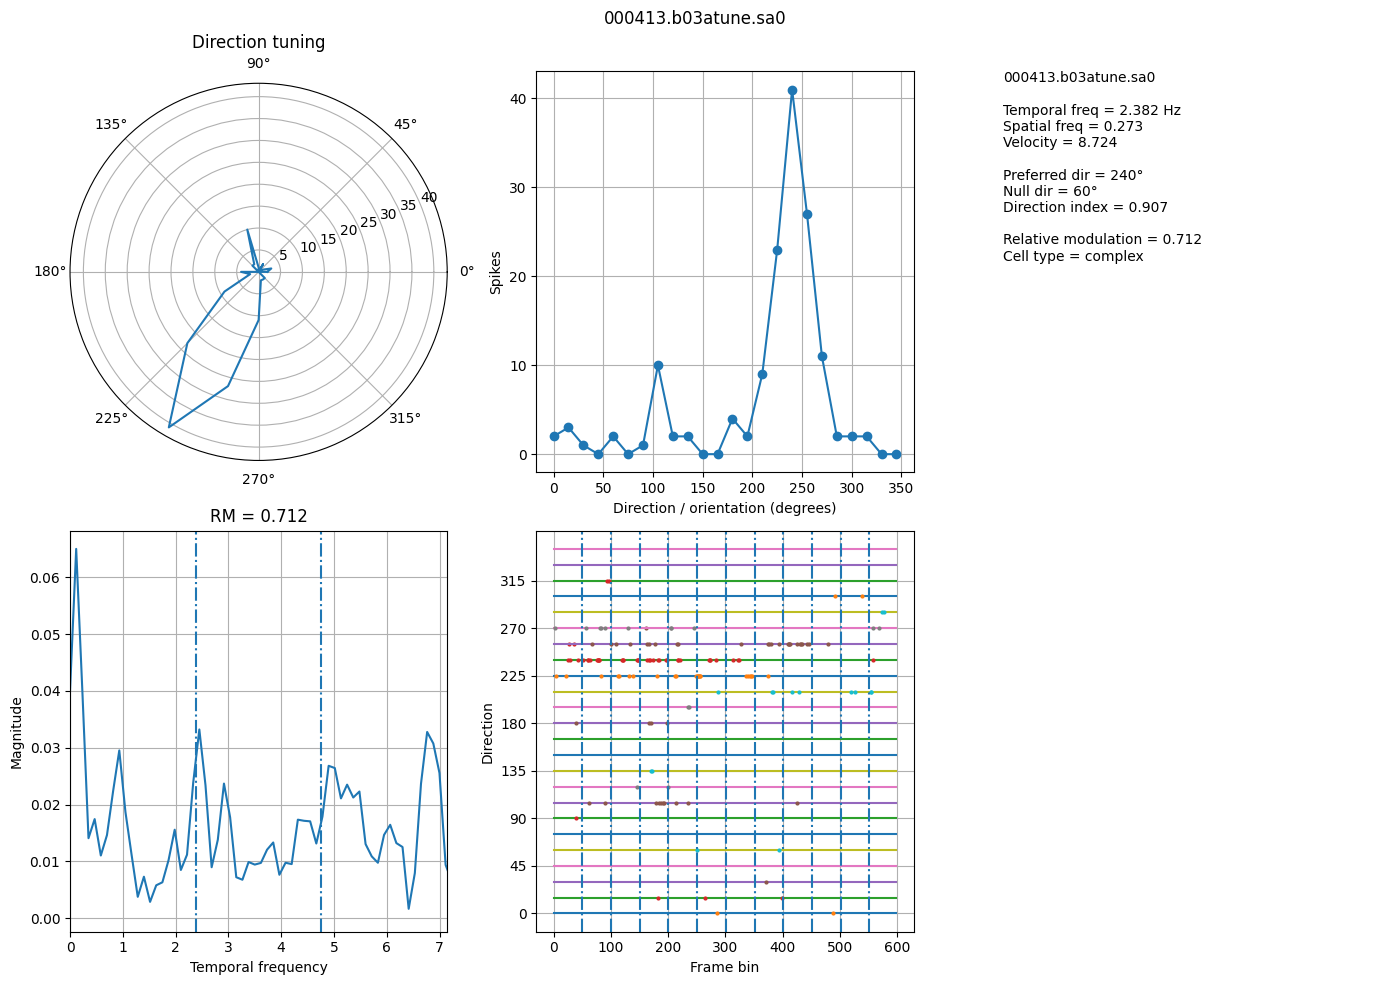

Preferred direction: 240.0
Null direction: 60.0
Direction index: 0.9069767441860465
Relative modulation: 0.7116498828292332
Cell type: complex


In [8]:
NEURON_PATH = PROJECT_ROOT / '1D_white_noise/Spike_and_Log_Files/000413.b03'


flog = retrieve_log(
    path=NEURON_PATH,
    filename="000413.b03atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)

print("Preferred direction:", info["prefdir"])
print("Null direction:", info["nulldir"])
print("Direction index:", info["dirind"])
print("Relative modulation:", info["relmod"])

if info["relmod"] < 1:
    print("Cell type: complex")
else:
    print("Cell type: simple")



filenames = [
    '000413.b03atune.sa0',
    '000413.b03bmsq1D.sa0',
    '000413.b03cmsq1D.sa0',
    '000413.b03dmsq1D.sa0',
    '000413.b03fmsq1D.sa0',
    '000413.b03hmsq1D.sa0',
]

paths = [NEURON_PATH / name for name in filenames]

In [9]:
trial_n = 0
responses = []

for p in paths:
    trial_n += 1
    spk_raw, spk_sec = load_spikes(p)

    n_spikes = len(spk_sec)
    duration = spk_sec[-1] - spk_sec[0]
    rate = n_spikes / duration

    responses.append(rate)

    print(p.name)
    print(f"spikes: {n_spikes}")
    print(f"duration: {duration:.2f} s")
    print(f"mean rate: {rate:.3f} spikes/s")
    print('----------------')
    print(f"--------trial {trial_n} -----------")

responses = np.array(responses)

print("\n=== Summary ===")
print("Mean firing rate (expectation):", responses.mean())
print("Std:", responses.std(ddof=1))

000413.b03atune.sa0
spikes: 174
duration: 166.78 s
mean rate: 1.043 spikes/s
----------------
--------trial 1 -----------
000413.b03bmsq1D.sa0
spikes: 609
duration: 543.77 s
mean rate: 1.120 spikes/s
----------------
--------trial 2 -----------
000413.b03cmsq1D.sa0
spikes: 587
duration: 541.84 s
mean rate: 1.083 spikes/s
----------------
--------trial 3 -----------
000413.b03dmsq1D.sa0
spikes: 681
duration: 544.72 s
mean rate: 1.250 spikes/s
----------------
--------trial 4 -----------
000413.b03fmsq1D.sa0
spikes: 532
duration: 547.07 s
mean rate: 0.972 spikes/s
----------------
--------trial 5 -----------
000413.b03hmsq1D.sa0
spikes: 544
duration: 547.26 s
mean rate: 0.994 spikes/s
----------------
--------trial 6 -----------

=== Summary ===
Mean firing rate (expectation): 1.077214077955549
Std: 0.10082536963165659


In [10]:
responses=np.array(responses)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


def gaussian_rate_convolution(spike_times, t_start=None, t_end=None, dt=0.001, sigma=0.2):
    """
    Gaussian-smoothed firing rate using binning + convolution.

    spike_times : spike times in seconds
    dt          : bin width in seconds
    sigma       : Gaussian std in seconds

    returns:
        t        : time axis
        rate     : firing rate in spikes/s
        counts   : binned spike counts
    """
    spike_times = np.asarray(spike_times)

    if t_start is None:
        t_start = spike_times[0]
    if t_end is None:
        t_end = spike_times[-1]

    bins = np.arange(t_start, t_end + dt, dt)
    counts, edges = np.histogram(spike_times, bins=bins)

    # Convert sigma from seconds to bins
    sigma_bins = sigma / dt

    # Smooth spike counts
    smoothed_counts = gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_bins,
        mode="constant"
    )

    # Convert counts/bin to spikes/second
    rate = smoothed_counts / dt

    # Bin centers
    t = edges[:-1] + dt / 2

    return t, rate, counts

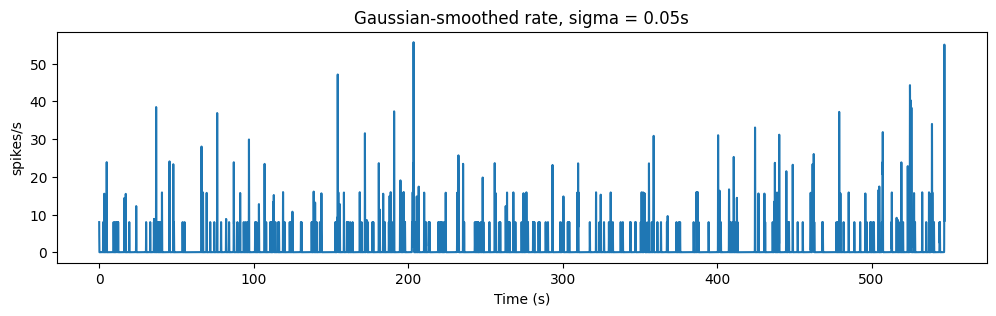

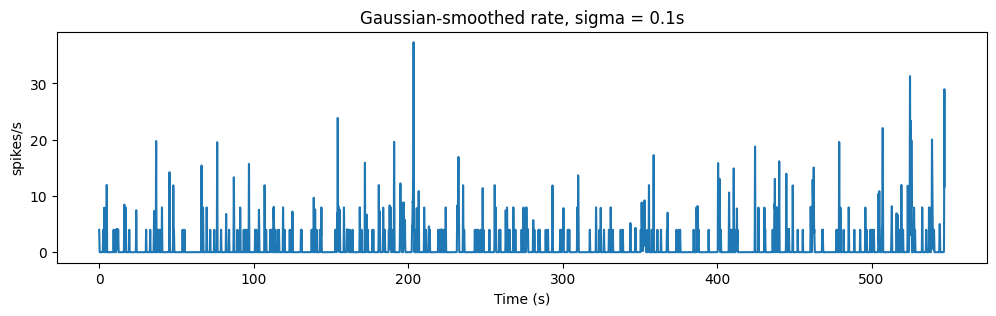

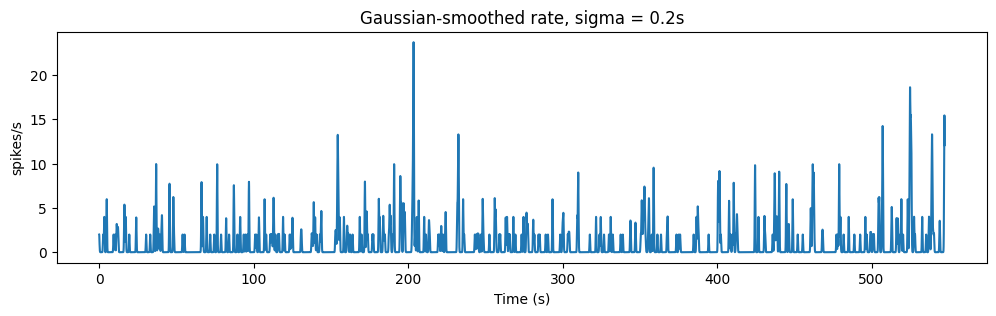

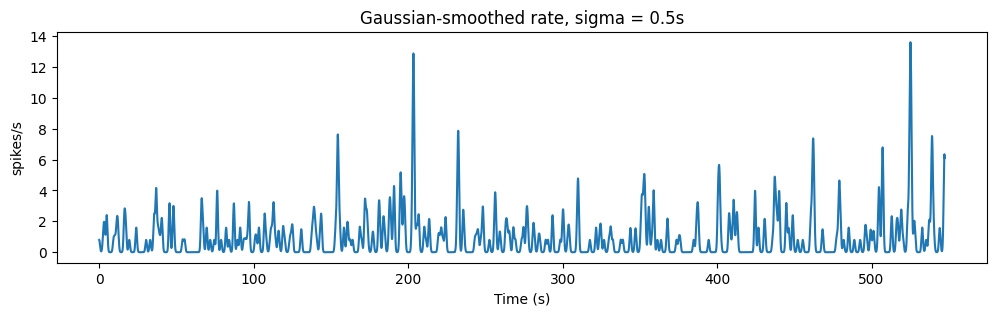

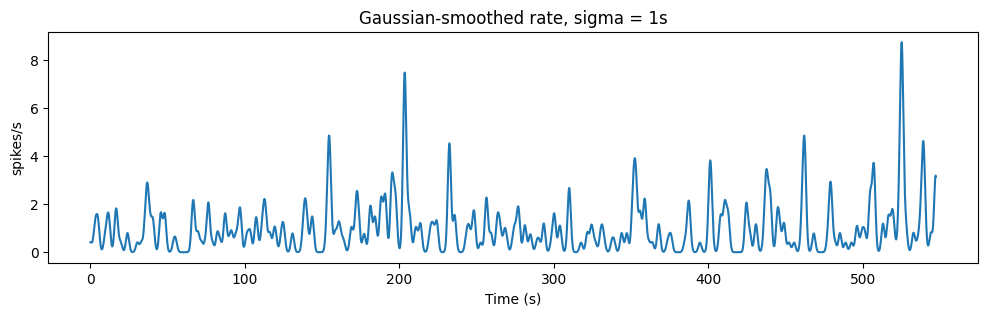

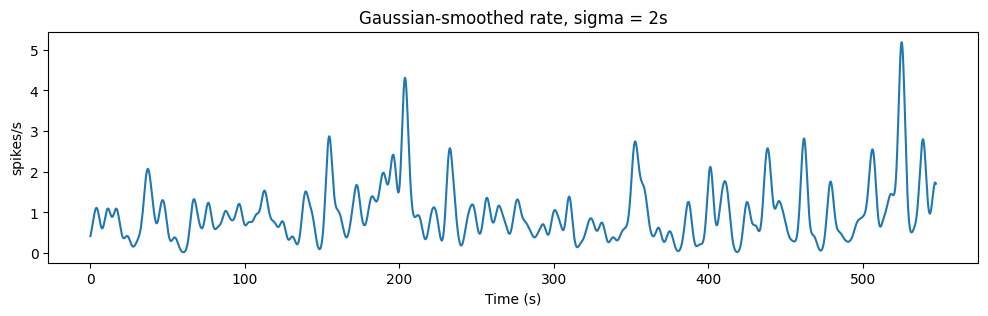

In [12]:

# NOTE THIS IS FOR NOW JUST THE LAST TRIAL, SINCE THERE IS A FOR LOOP ABOVE 

for sigma in [0.05, 0.1, 0.2, 0.5,1,2]:
    t, rate, _ = gaussian_rate_convolution(spk_sec, dt=0.001, sigma=sigma)

    plt.figure(figsize=(12, 3))
    plt.plot(t, rate)
    plt.title(f"Gaussian-smoothed rate, sigma = {sigma}s")
    plt.xlabel("Time (s)")
    plt.ylabel("spikes/s")
    plt.show()

In [13]:
#plt.imshow(msq1D.T, aspect='auto', cmap='gray')

# to do 

- STA 
- OPTIMAL KERNEL 

the standard method used to determine the optimal kernel is to measure the spike-triggered average stimulus in response to a white-noise stimulus.

- STATIC NONLINEARITY

- BETTER TUNING CURVE 

- POISSON?????

# Spike-Triggered Average (STA)

In [14]:
import scipy.io

STIM_PATH  = PROJECT_ROOT / '1D_white_noise/Stimulus_Files/msq1D.mat'
NEURON_PATH = PROJECT_ROOT / '1D_white_noise/Spike_and_Log_Files/000413.b03'

msq1D_stim = scipy.io.loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1

log_lines         = load_log_lines(NEURON_PATH / '000413.b03bmsq1D.log')
remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)

print(f'Stimulus: {msq1D_stim.shape}  (frames × bars)')
print(f'Effective frame rate: {frame_rate:.4f} Hz')
print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7199 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


In [15]:
msq1D_filenames = [
    '000413.b03bmsq1D.sa0',
    '000413.b03cmsq1D.sa0',
    '000413.b03dmsq1D.sa0',
    '000413.b03fmsq1D.sa0',
    '000413.b03hmsq1D.sa0',
]

n_lags = 25  # frames (~419 ms at 59.72 Hz)


def compute_sta(spike_files, stim, n_lags, frame_rate):
    T, N        = stim.shape
    lag_offsets = np.arange(1, n_lags + 1)       # [1, 2, ..., n_lags]; row 0 = most recent
    sta_accum   = np.zeros((n_lags, N))
    n_total     = 0

    for path in spike_files:
        _, spk_sec = load_spikes(path)
        frames = np.floor(spk_sec * frame_rate).astype(int)
        valid  = (frames >= n_lags) & (frames < T)
        frames = frames[valid]

        windows    = frames[:, np.newaxis] - lag_offsets[np.newaxis, :]   # (n_spikes, n_lags)
        sta_accum += stim[windows].sum(axis=0)                            # (n_lags, N)
        n_total   += len(frames)
        print(f'  {path.name}: {len(frames)} spikes')

    print(f'\nTotal spikes used: {n_total}')
    return sta_accum / n_total, n_total


paths = [NEURON_PATH / f for f in msq1D_filenames]
sta, n_spikes = compute_sta(paths, msq1D_stim, n_lags, frame_rate)
print(f'STA shape: {sta.shape}  (lags × bars)')

  000413.b03bmsq1D.sa0: 608 spikes
  000413.b03cmsq1D.sa0: 587 spikes
  000413.b03dmsq1D.sa0: 680 spikes
  000413.b03fmsq1D.sa0: 532 spikes
  000413.b03hmsq1D.sa0: 543 spikes

Total spikes used: 2950
STA shape: (25, 16)  (lags × bars)


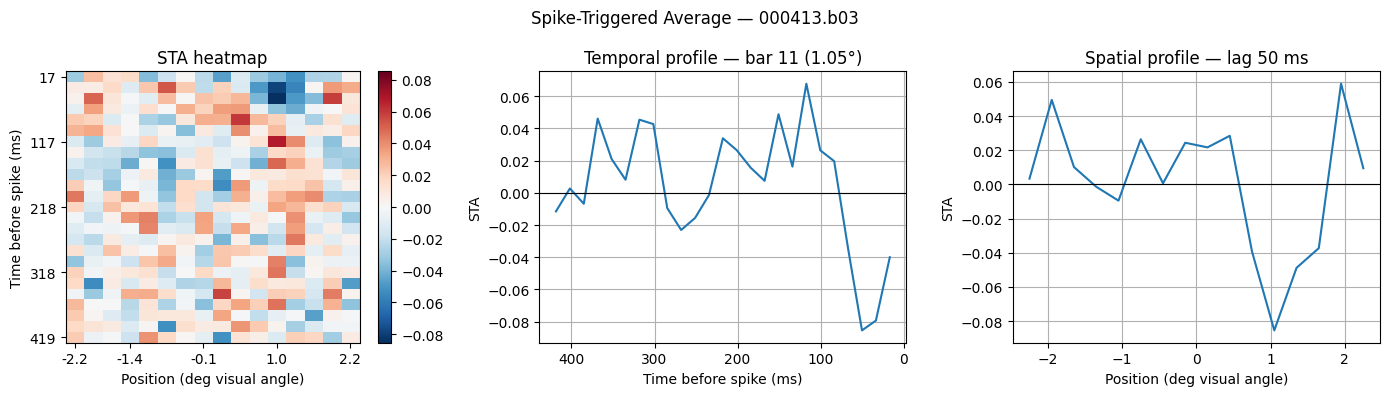

In [16]:
bar_positions = np.linspace(-sti_w_deg / 2, sti_w_deg / 2, 16)   # bar centres in degrees
lags_ms       = np.arange(1, n_lags + 1) / frame_rate * 1000      # ms before spike

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Spike-Triggered Average — 000413.b03')

# Spatiotemporal heatmap
ax = axes[0]
vmax = np.abs(sta).max()
im   = ax.imshow(sta, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                 interpolation='nearest', origin='upper')
xtick_idx = np.linspace(0, 15, 5).astype(int)
ax.set_xticks(xtick_idx)
ax.set_xticklabels([f'{bar_positions[i]:.1f}' for i in xtick_idx])
ax.set_xlabel('Position (deg visual angle)')
ytick_idx = np.linspace(0, n_lags - 1, 5).astype(int)
ax.set_yticks(ytick_idx)
ax.set_yticklabels([f'{lags_ms[i]:.0f}' for i in ytick_idx])
ax.set_ylabel('Time before spike (ms)')
ax.set_title('STA heatmap')
plt.colorbar(im, ax=ax)

# Temporal profile at peak spatial position
ax = axes[1]
peak_bar = int(np.abs(sta).max(axis=0).argmax())
ax.plot(lags_ms, sta[:, peak_bar])
ax.axhline(0, color='k', linewidth=0.8)
ax.invert_xaxis()
ax.set_xlabel('Time before spike (ms)')
ax.set_ylabel('STA')
ax.set_title(f'Temporal profile — bar {peak_bar} ({bar_positions[peak_bar]:.2f}°)')
ax.grid(True)

# Spatial profile at peak lag
ax = axes[2]
peak_lag = int(np.abs(sta).max(axis=1).argmax())
ax.plot(bar_positions, sta[peak_lag])
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Position (deg visual angle)')
ax.set_ylabel('STA')
ax.set_title(f'Spatial profile — lag {lags_ms[peak_lag]:.0f} ms')
ax.grid(True)

plt.tight_layout()
plt.show()

## Optimal Kernel Estimation

Two methods are compared on the 5 msq1D runs of neuron 000413.b03 using **leave-one-run-out cross-validation**:

| Method | Model class | Optimisation |
|---|---|---|
| STA | Linear (closed form) | Cross-correlation; optimal for white noise |
| Ridge | Linear + L2 penalty | Normal equations; α tuned by CV |

Evaluation metric: Pearson r between the model's predicted firing rate and the Gaussian-smoothed spike train of the held-out run (σ = 3 frames ≈ 50 ms).

In [17]:
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

# ── dimensions ───────────────────────────────────────────────────────────────
T, N_bars  = msq1D_stim.shape          # 32767, 16
n_features = n_lags * N_bars            # 400
T_eff      = T - n_lags                 # 32742 frames per run with full history

# ── full-run design matrix (same stimulus for every run) ─────────────────────
t_idx   = np.arange(n_lags, T)
wins    = t_idx[:, np.newaxis] - np.arange(1, n_lags + 1)   # (T_eff, n_lags)
X_flat  = msq1D_stim[wins].astype(np.float32).reshape(T_eff, n_features)

# ── per-run spike trains ─────────────────────────────────────────────────────
run_ys = []
for path in paths:
    _, spk_sec = load_spikes(path)
    frames     = np.floor(spk_sec * frame_rate).astype(int)
    frames     = frames[(frames >= n_lags) & (frames < T)] - n_lags
    y          = np.zeros(T_eff, dtype=np.float32)
    np.add.at(y, frames, 1)
    run_ys.append(y)
run_ys = np.stack(run_ys)              # (5, T_eff)
n_runs = run_ys.shape[0]

sigma_smooth = 3                        # frames ≈ 50 ms at 59.72 Hz
run_rates    = np.stack([gaussian_filter1d(y.astype(float), sigma_smooth)
                         for y in run_ys])   # (5, T_eff)

# ── precompute for ridge (avoids rebuilding X for each fold / α) ─────────────
XtX   = X_flat.T @ X_flat              # (400, 400), computed once
Xty_r = np.stack([X_flat.T @ run_ys[i] for i in range(n_runs)])  # (5, 400)

print(f'X_flat  : {X_flat.shape}   {X_flat.nbytes // 1024 // 1024} MB')
print(f'run_ys  : {run_ys.shape}   spikes/run: {run_ys.sum(axis=1).astype(int).tolist()}')
print(f'mean spike rate: {run_ys.mean():.5f} spikes/frame')

X_flat  : (32742, 400)   49 MB
run_ys  : (5, 32742)   spikes/run: [608, 587, 680, 532, 543]
mean spike rate: 0.01802 spikes/frame


## Standard method — STA as linear predictor

For an exactly white-noise stimulus the STA equals the Wiener filter — the optimal linear kernel. No whitening step is required. Prediction performance (Pearson r between the generator signal `g(t) = X(t)·w_STA` and the test-run smoothed firing rate) sets the baseline for linear models.

In [18]:
# Proper CV: recompute STA from training runs only (no data leakage)
# For white noise: STA_train = Xty_train / n_train_spikes = (X.T @ y_train) / n_train_spikes
# This is equivalent to ridge with α → 0, computed from held-out training data.

sta_rs = []
for test_i in range(n_runs):
    train_idx      = [i for i in range(n_runs) if i != test_i]
    n_train_spikes = run_ys[train_idx].sum()
    sta_train_flat = Xty_r[train_idx].sum(axis=0) / (n_train_spikes + 1e-10)

    g = X_flat @ sta_train_flat.astype(np.float32)
    r = pearsonr(g, run_rates[test_i]).statistic
    sta_rs.append(r)
    print(f'  fold {test_i}: r = {r:.4f}')

sta_rs = np.array(sta_rs)
print(f'\nSTA   r = {sta_rs.mean():.4f} ± {sta_rs.std():.4f}')
print('(per-fold STA from training runs only — no data leakage)')

  fold 0: r = 0.0239
  fold 1: r = 0.0102
  fold 2: r = 0.0123
  fold 3: r = 0.0245
  fold 4: r = 0.0149

STA   r = 0.0172 ± 0.0059
(per-fold STA from training runs only — no data leakage)


## Ridge regression

For exactly white-noise stimulus `X^T X ≈ n·I`, so the ridge solution is theoretically a scaled STA. Cross-validation over α still finds the optimal shrinkage factor and confirms that the STA is not over-fitting noise. The kernel shape is expected to be identical to the STA; differences indicate finite-sample deviations from perfect whiteness.

Ridge  best α = 1e+06   r = 0.0172 ± 0.0059


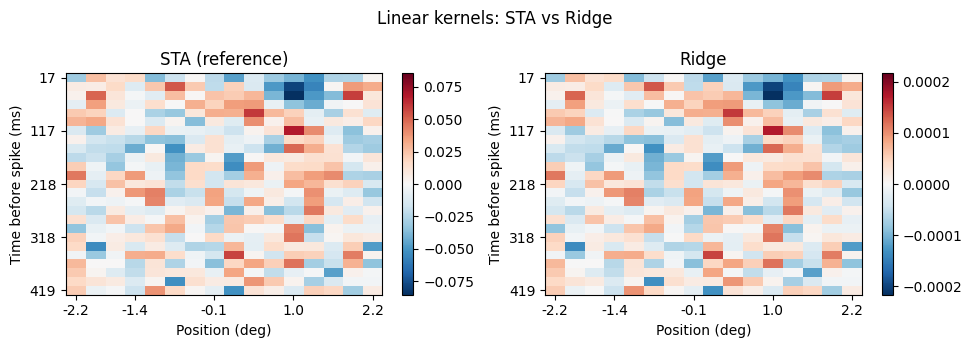

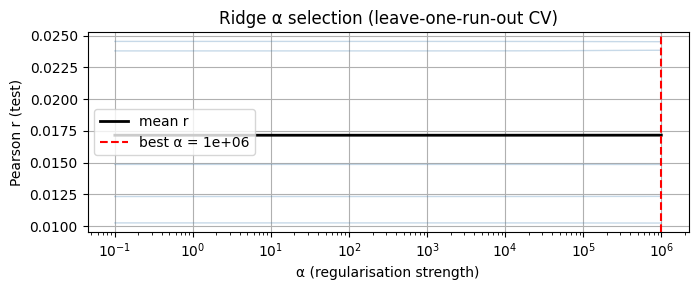

In [19]:
alphas = np.logspace(-1, 6, 35)
I400   = np.eye(n_features, dtype=np.float32)

ridge_rs = np.zeros((n_runs, len(alphas)))

for test_i in range(n_runs):
    train_idx   = [i for i in range(n_runs) if i != test_i]
    k           = len(train_idx)
    A_train     = k * XtX
    Xty_train   = Xty_r[train_idx].sum(axis=0)

    for j, alpha in enumerate(alphas):
        w = np.linalg.solve(A_train + alpha * I400, Xty_train)
        r = pearsonr(X_flat @ w, run_rates[test_i]).statistic
        ridge_rs[test_i, j] = r

mean_rs       = ridge_rs.mean(axis=0)
best_j        = int(mean_rs.argmax())
best_alpha_cv = alphas[best_j]
ridge_rs_cv   = ridge_rs[:, best_j]
print(f'Ridge  best α = {best_alpha_cv:.3g}   r = {mean_rs[best_j]:.4f} ± {ridge_rs_cv.std():.4f}')

# Final kernel on all runs with best α
w_ridge    = np.linalg.solve(n_runs * XtX + best_alpha_cv * I400, Xty_r.sum(axis=0))
w_ridge_2d = w_ridge.reshape(n_lags, N_bars)   # (25, 16)

# ── kernel comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, kernel, title in zip(axes,
                              [sta,         w_ridge_2d],
                              ['STA (reference)', 'Ridge']):
    vmax = np.abs(kernel).max()
    im   = ax.imshow(kernel, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                     interpolation='nearest', origin='upper')
    xtick_idx = np.linspace(0, 15, 5).astype(int)
    ax.set_xticks(xtick_idx)
    ax.set_xticklabels([f'{bar_positions[i]:.1f}' for i in xtick_idx])
    ax.set_xlabel('Position (deg)')
    ytick_idx = np.linspace(0, n_lags - 1, 5).astype(int)
    ax.set_yticks(ytick_idx)
    ax.set_yticklabels([f'{lags_ms[i]:.0f}' for i in ytick_idx])
    ax.set_ylabel('Time before spike (ms)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle('Linear kernels: STA vs Ridge')
plt.tight_layout()
plt.show()

# ── α selection curve ────────────────────────────────────────────────────────
plt.figure(figsize=(7, 3))
for fold_r in ridge_rs:
    plt.semilogx(alphas, fold_r, alpha=0.3, color='steelblue', linewidth=1)
plt.semilogx(alphas, mean_rs, 'k-', linewidth=2, label='mean r')
plt.axvline(best_alpha_cv, color='red', linestyle='--',
            label=f'best α = {best_alpha_cv:.1g}')
plt.xlabel('α (regularisation strength)')
plt.ylabel('Pearson r (test)')
plt.title('Ridge α selection (leave-one-run-out CV)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## Comparative analysis

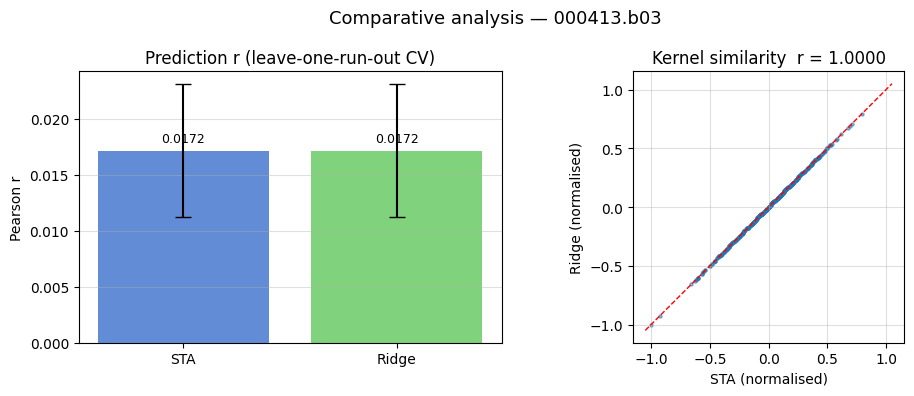

── Summary ─────────────────────────────────────────────────────
  STA       r = 0.0172 ± 0.0059  [0.023854361899710658, 0.010248523943738992, 0.012349297433165018, 0.02452005386306315, 0.014857572576555012]
  Ridge     r = 0.0172 ± 0.0059  [0.02384784623323049, 0.010250003025291192, 0.012348019998838933, 0.024522802929796614, 0.014858277965830584]

  Best method: STA


In [20]:
method_rs = {'STA': sta_rs, 'Ridge': ridge_rs_cv}
labels    = list(method_rs.keys())
means     = [v.mean() for v in method_rs.values()]
stds      = [v.std()  for v in method_rs.values()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Comparative analysis — 000413.b03', fontsize=13)

# ── bar chart ────────────────────────────────────────────────────────────────
ax     = axes[0]
colors = ['#4878CF', '#6ACC65']
bars   = ax.bar(labels, means, yerr=stds, capsize=6, color=colors, alpha=0.85)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 5e-4,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Pearson r')
ax.set_title('Prediction r (leave-one-run-out CV)')
ax.grid(axis='y', alpha=0.4)

# ── STA vs Ridge kernel scatter (white noise → should be proportional) ───────
ax    = axes[1]
s_n   = sta.ravel()        / (np.abs(sta).max()        + 1e-10)
r_n   = w_ridge_2d.ravel() / (np.abs(w_ridge_2d).max() + 1e-10)
ax.scatter(s_n, r_n, s=5, alpha=0.5)
lim   = max(np.abs(s_n).max(), np.abs(r_n).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1)
r_kr  = pearsonr(s_n, r_n).statistic
ax.set_xlabel('STA (normalised)');  ax.set_ylabel('Ridge (normalised)')
ax.set_title(f'Kernel similarity  r = {r_kr:.4f}')
ax.set_aspect('equal');  ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print('── Summary ─────────────────────────────────────────────────────')
for name, rs in method_rs.items():
    print(f'  {name:8s}  r = {rs.mean():.4f} ± {rs.std():.4f}  {rs.tolist()}')

best = labels[int(np.argmax(means))]
print(f'\n  Best method: {best}')

# 2D stimulus for neuron a2 2003